# 🏦 Loan Default Risk Prediction

## 📌 Overview
This project aims to predict whether a customer will default on a loan using financial, demographic, and historical loan data.  

The goal is to build a model that helps financial institutions identify high-risk customers and reduce potential losses.

In [1]:
# Importing Liberaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 💼 Business Problem

Loan default is a major challenge for financial institutions. Incorrect lending decisions can lead to significant financial losses.

### Objective:
- Identify customers likely to default
- Improve risk assessment
- Support better lending decisions

### Key Challenge:
The dataset is **highly imbalanced (~8% defaults)**, making it difficult for standard models to detect risky customers.

## 📂 Dataset Description

The dataset consists of:

- **Application Data**: Customer demographics and financial details
- **Previous Loan Data**: Historical loan behavior

### Key Features:
- Income, Credit Amount, Annuity
- Employment and Age
- External Credit Scores (EXT_SOURCE)
- Previous loan history

### Target Variable:
- `TARGET = 1` → Default
- `TARGET = 0` → No Default

In [3]:
cols_to_keep = ['SK_ID_CURR',
 'TARGET',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'DAYS_BIRTH',
 'CODE_GENDER',
 'NAME_FAMILY_STATUS',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'NAME_EDUCATION_TYPE',
 'NAME_INCOME_TYPE',
 'OCCUPATION_TYPE',
 'DAYS_EMPLOYED',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_HOUSING_TYPE',
 'REGION_RATING_CLIENT',
 'REGION_POPULATION_RELATIVE',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'DEF_30_CNT_SOCIAL_CIRCLE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'NAME_CONTRACT_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START']


In [4]:
loan_applications = pd.read_csv('E:\\Loan default risk analysis ml project\\data\\application_data.csv', usecols=cols_to_keep)

In [5]:
loan_applications.head(2)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,Laborers,1.0,2,WEDNESDAY,10,0.083037,0.262949,0.139376,2.0,2.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,Core staff,2.0,1,MONDAY,11,0.311267,0.622246,NaN,1.0,0.0


In [6]:
categorical_cols = [col for col in loan_applications.columns if loan_applications[col].dtype == 'object']
categorical_cols.append('REGION_RATING_CLIENT')
categorical_cols.append('HOUR_APPR_PROCESS_START')
numerical_cols = [col for col in loan_applications.columns if col not in categorical_cols and col not in ['TARGET','SK_ID_CURR']]

In [7]:
loan_applications.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,306490.000000,306490.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,2.152665,2.052463,12.063419,0.502130,5.143927e-01,0.510853,1.422245,0.143421
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,0.910682,0.509034,3.265832,0.211062,1.910602e-01,0.194844,2.400989,0.446698
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,1.000000,1.000000,0.000000,0.014568,8.173617e-08,0.000527,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,2.000000,2.000000,10.000000,0.334007,3.924574e-01,0.370650,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,2.000000,2.000000,12.000000,0.505998,5.659614e-01,0.535276,0.000000,0.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,3.000000,2.000000,14.000000,0.675053,6.636171e-01,0.669057,2.000000,0.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,20.000000,3.000000,23.000000,0.962693,8.549997e-01,0.896010,348.000000,34.000000


In [8]:
print(loan_applications.shape)

(307511, 28)


## 🧹 Data Cleaning

Steps performed:

- Removed invalid categories (e.g., XNA, Unknown)
- Handled missing values:
  - Numerical → median imputation
  - Categorical → "Unknown"
- Fixed anomalies:
  - `DAYS_EMPLOYED = 365243` replaced with NaN
- Capped extreme outliers (income)
- Created missing value indicators where needed

This ensured a clean and consistent dataset for modeling.

In [9]:
print(loan_applications['TARGET'].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [10]:
for i in categorical_cols:
    print(loan_applications[i].value_counts())
    print('---------------------')

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
---------------------
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
---------------------
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
---------------------
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64
---------------------
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64
---------------------
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64
---------------------
NAME_FAMILY_STATUS
Marrie

In [11]:
loan_applications.drop(loan_applications.index[loan_applications['CODE_GENDER'] == 'XNA'], axis=0, inplace=True)

In [12]:
loan_applications.drop(loan_applications.index[loan_applications['NAME_FAMILY_STATUS'] == 'Unknown'], axis=0, inplace=True)

In [13]:
loan_applications['AMT_INCOME_TOTAL'].groupby(loan_applications['TARGET']).mean()

TARGET
0    169076.360183
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64

In [14]:
loan_applications.isna().mean().sort_values(ascending=False)

EXT_SOURCE_1                  0.563812
OCCUPATION_TYPE               0.313455
EXT_SOURCE_3                  0.198254
OBS_30_CNT_SOCIAL_CIRCLE      0.003320
DEF_30_CNT_SOCIAL_CIRCLE      0.003320
EXT_SOURCE_2                  0.002146
AMT_GOODS_PRICE               0.000898
AMT_ANNUITY                   0.000039
CODE_GENDER                   0.000000
NAME_CONTRACT_TYPE            0.000000
SK_ID_CURR                    0.000000
TARGET                        0.000000
NAME_INCOME_TYPE              0.000000
AMT_CREDIT                    0.000000
CNT_CHILDREN                  0.000000
AMT_INCOME_TOTAL              0.000000
FLAG_OWN_REALTY               0.000000
FLAG_OWN_CAR                  0.000000
NAME_HOUSING_TYPE             0.000000
NAME_EDUCATION_TYPE           0.000000
CNT_FAM_MEMBERS               0.000000
DAYS_EMPLOYED                 0.000000
DAYS_BIRTH                    0.000000
REGION_POPULATION_RELATIVE    0.000000
NAME_FAMILY_STATUS            0.000000
HOUR_APPR_PROCESS_START  

In [15]:
cols_to_fill_numeric = ['EXT_SOURCE_2',
'AMT_GOODS_PRICE',
'AMT_ANNUITY',
'OBS_30_CNT_SOCIAL_CIRCLE',
'DEF_30_CNT_SOCIAL_CIRCLE',
'EXT_SOURCE_3',
'EXT_SOURCE_1',
]

for i in cols_to_fill_numeric:
    loan_applications[i] = loan_applications[i].fillna(loan_applications[i].median())
    
loan_applications['OCCUPATION_TYPE'] = loan_applications['OCCUPATION_TYPE'].fillna('Unknown')

In [16]:
loan_applications['DAYS_EMPLOYED'].describe()

count    307505.000000
mean      63816.348794
std      141276.836143
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [17]:
print(loan_applications['DAYS_EMPLOYED'].value_counts().sort_values(ascending=False).head())
print('---------------------')
print(loan_applications['DAYS_EMPLOYED'].value_counts().sort_values(ascending=False).tail())

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64
---------------------
DAYS_EMPLOYED
-7794     1
-11707    1
-13385    1
-9985     1
-9672     1
Name: count, dtype: int64


In [18]:
loan_applications['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
loan_applications['EMPLOYED_MISSING'] = loan_applications['DAYS_EMPLOYED'].isna().astype(int)
loan_applications['DAYS_EMPLOYED'] = loan_applications['DAYS_EMPLOYED'].fillna(loan_applications['DAYS_EMPLOYED'].median())
loan_applications['YEARS_EMPLOYED'] = (-loan_applications['DAYS_EMPLOYED']) / 365

In [19]:
loan_applications['YEARS_BIRTH'] = (-loan_applications['DAYS_BIRTH']) / 365

In [20]:
loan_applications.loc[loan_applications['YEARS_EMPLOYED'] > loan_applications['YEARS_BIRTH'],:]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,EMPLOYED_MISSING,YEARS_EMPLOYED,YEARS_BIRTH


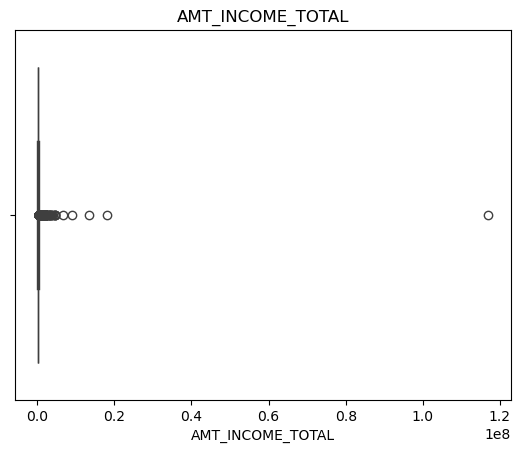

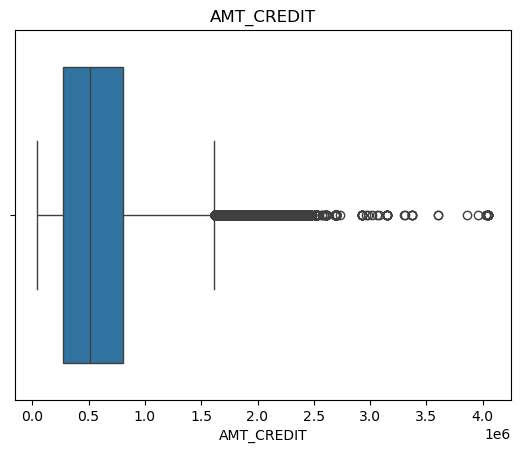

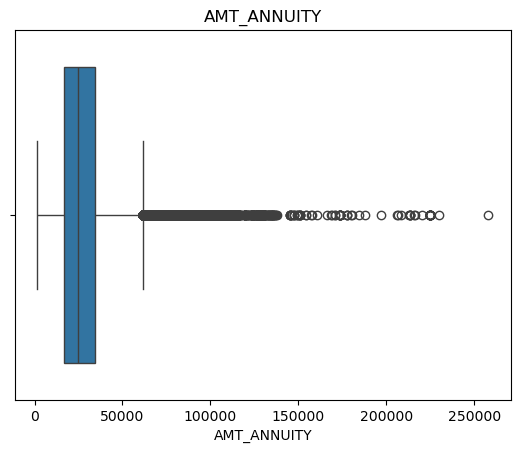

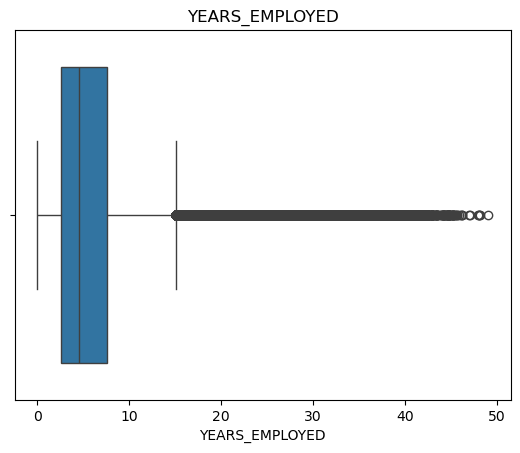

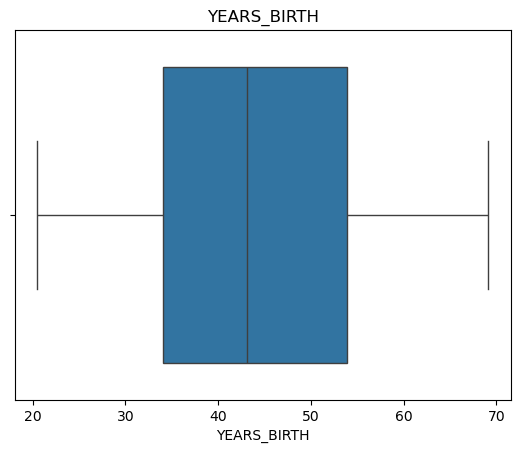

In [21]:
for i in ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','YEARS_EMPLOYED','YEARS_BIRTH']:
    sns.boxplot(x=loan_applications[i])
    plt.title(i)
    plt.show()

In [22]:
loan_applications['YEARS_EMPLOYED'].describe(percentiles=[0.9,0.95,0.99])

count    307505.000000
mean          6.168746
std           5.852502
min          -0.000000
50%           4.515068
90%          13.372603
95%          18.470685
99%          29.849205
max          49.073973
Name: YEARS_EMPLOYED, dtype: float64

In [23]:
cap_value = loan_applications['AMT_INCOME_TOTAL'].quantile(0.99)
loan_applications.loc[loan_applications['AMT_INCOME_TOTAL'] > cap_value, 'AMT_INCOME_TOTAL'] = cap_value

## ⚙️ Feature Engineering

Created meaningful features to improve model performance:

### Financial Ratios:
- `ANNUITY_BURDEN` = Annuity / Income  
- `INCOME_TO_CREDIT_RATIO` = Income / Credit  

### Employment:
- Converted employment days into years
- Created missing employment flag

### Previous Loan Aggregation:
- Average, max, and total previous credit
- Number of past applications
- Historical borrowing behavior

These features helped capture financial stress and repayment capacity.

In [24]:
loan_applications['INCOME_TO_CREDIT_RATIO'] = loan_applications['AMT_INCOME_TOTAL'] / loan_applications['AMT_CREDIT']
loan_applications['ANNUITY_BURDEN'] = loan_applications['AMT_ANNUITY'] / loan_applications['AMT_INCOME_TOTAL']

In [25]:
loan_applications[['INCOME_TO_CREDIT_RATIO','ANNUITY_BURDEN']].describe()

,INCOME_TO_CREDIT_RATIO,ANNUITY_BURDEN
count,307505.000000,307505.000000
mean,0.395994,0.181223
std,0.327731,0.094398
min,0.011801,0.008700
25%,0.193577,0.115273
50%,0.305206,0.162933
75%,0.493294,0.229156
max,10.500000,1.875965


In [26]:
print(loan_applications['INCOME_TO_CREDIT_RATIO'].groupby(loan_applications['TARGET']).mean())
print(loan_applications['INCOME_TO_CREDIT_RATIO'].groupby(loan_applications['TARGET']).median())
print('--------------------------------------------------------')
print(loan_applications['ANNUITY_BURDEN'].groupby(loan_applications['TARGET']).mean())
print(loan_applications['ANNUITY_BURDEN'].groupby(loan_applications['TARGET']).median())


TARGET
0    0.396865
1    0.386076
Name: INCOME_TO_CREDIT_RATIO, dtype: float64
TARGET
0    0.304911
1    0.307018
Name: INCOME_TO_CREDIT_RATIO, dtype: float64
--------------------------------------------------------
TARGET
0    0.180835
1    0.185635
Name: ANNUITY_BURDEN, dtype: float64
TARGET
0    0.162375
1    0.169350
Name: ANNUITY_BURDEN, dtype: float64


In [27]:
loan_applications['FLAG_OWN_CAR'] = loan_applications['FLAG_OWN_CAR'].apply(lambda x: 1 if x == 'Y' else 0,)
loan_applications['FLAG_OWN_REALTY']=loan_applications['FLAG_OWN_REALTY'].apply(lambda x: 1 if x == 'Y' else 0)

loan_applications.head(2)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,EMPLOYED_MISSING,YEARS_EMPLOYED,YEARS_BIRTH,INCOME_TO_CREDIT_RATIO,ANNUITY_BURDEN
0,100002,1,Cash loans,M,0,1,0,202500.0,406597.5,24700.5,351000.0,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,Laborers,1.0,2,WEDNESDAY,10,0.083037,0.262949,0.139376,2.0,2.0,0,1.745205,25.920548,0.498036,0.121978
1,100003,0,Cash loans,F,0,0,0,270000.0,1293502.5,35698.5,1129500.0,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.0,Core staff,2.0,1,MONDAY,11,0.311267,0.622246,0.535276,1.0,0.0,0,3.254795,45.931507,0.208736,0.132217


In [28]:
cols = ['NAME_CONTRACT_TYPE',
'CODE_GENDER',
'NAME_FAMILY_STATUS',
'NAME_HOUSING_TYPE',
'WEEKDAY_APPR_PROCESS_START']
dum = pd.get_dummies(loan_applications[cols], drop_first=True)
loan_applications = pd.concat([loan_applications,dum],axis=1)
loan_applications.drop(columns=cols, inplace=True)
loan_applications.head(2)

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,EMPLOYED_MISSING,YEARS_EMPLOYED,YEARS_BIRTH,INCOME_TO_CREDIT_RATIO,ANNUITY_BURDEN,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY
0,100002,1,0,1,0,202500.0,406597.5,24700.5,351000.0,Working,Secondary / secondary special,0.018801,-9461,-637.0,Laborers,1.0,2,10,0.083037,0.262949,0.139376,2.0,2.0,0,1.745205,25.920548,0.498036,0.121978,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True
1,100003,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,State servant,Higher education,0.003541,-16765,-1188.0,Core staff,2.0,1,11,0.311267,0.622246,0.535276,1.0,0.0,0,3.254795,45.931507,0.208736,0.132217,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False


In [29]:
for col in ['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','OCCUPATION_TYPE']:
    print(col, loan_applications[col].nunique())

NAME_INCOME_TYPE 8
NAME_EDUCATION_TYPE 5
OCCUPATION_TYPE 19


In [30]:
cols2 = ['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','OCCUPATION_TYPE']

dum2 = pd.get_dummies(loan_applications[cols2], drop_first=True)
loan_applications = pd.concat([loan_applications, dum2], axis=1)
loan_applications.drop(columns=cols2, inplace=True)

In [31]:
loan_applications.head(2)

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,EMPLOYED_MISSING,YEARS_EMPLOYED,YEARS_BIRTH,INCOME_TO_CREDIT_RATIO,ANNUITY_BURDEN,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,100002,1,0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,1.0,2,10,0.083037,0.262949,0.139376,2.0,2.0,0,1.745205,25.920548,0.498036,0.121978,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,100003,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,2.0,1,11,0.311267,0.622246,0.535276,1.0,0.0,0,3.254795,45.931507,0.208736,0.132217,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [32]:
prev_cols = ['SK_ID_CURR','NAME_CONTRACT_STATUS','AMT_CREDIT','AMT_APPLICATION','AMT_ANNUITY']

In [33]:
prev_data = pd.read_csv('E:\\Loan default risk analysis ml project\\data\\previous_application.csv',usecols=prev_cols)

In [34]:
prev_data.head(2)

,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,NAME_CONTRACT_STATUS
0,271877,1730.430,17145.0,17145.0,Approved
1,108129,25188.615,607500.0,679671.0,Approved


In [35]:
previous_loans_agg = prev_data.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT': ['mean','max','sum'],
    'AMT_APPLICATION': ['mean','max'],
    'AMT_ANNUITY': ['mean'],
    'SK_ID_CURR': ['count']
})

previous_loans_agg.columns = [
    'AMT_CREDIT_MEAN',
    'AMT_CREDIT_MAX',
    'AMT_CREDIT_SUM',
    'AMT_APPLICATION_MEAN',
    'AMT_APPLICATION_MAX',
    'AMT_ANNUITY_MEAN',
    'PREV_APP_COUNT'
]

previous_loans_agg = previous_loans_agg.reset_index()

In [36]:
dataset = pd.merge(loan_applications, previous_loans_agg, how='left', on='SK_ID_CURR')

dataset.head(2)

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,EMPLOYED_MISSING,YEARS_EMPLOYED,YEARS_BIRTH,INCOME_TO_CREDIT_RATIO,ANNUITY_BURDEN,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff,AMT_CREDIT_MEAN,AMT_CREDIT_MAX,AMT_CREDIT_SUM,AMT_APPLICATION_MEAN,AMT_APPLICATION_MAX,AMT_ANNUITY_MEAN,PREV_APP_COUNT
0,100002,1,0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,1.0,2,10,0.083037,0.262949,0.139376,2.0,2.0,0,1.745205,25.920548,0.498036,0.121978,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,179055.0,179055.0,179055.0,179055.0,179055.0,9251.775,1.0
1,100003,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,2.0,1,11,0.311267,0.622246,0.535276,1.0,0.0,0,3.254795,45.931507,0.208736,0.132217,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,484191.0,1035882.0,1452573.0,435436.5,900000.0,56553.990,3.0


In [37]:
dataset.shape

(307505, 78)

In [38]:
dataset.isna().mean().sort_values(ascending=False).head()

AMT_ANNUITY_MEAN        0.054858
AMT_CREDIT_SUM          0.053502
AMT_CREDIT_MEAN         0.053502
AMT_APPLICATION_MEAN    0.053502
AMT_APPLICATION_MAX     0.053502
dtype: float64

In [39]:
dataset.fillna(0, inplace=True)

## 🤖 Modeling Approach

Two models were used:

### 1. Logistic Regression
- Used as baseline model
- Applied `class_weight='balanced'` to handle imbalance
- Applied feature scaling
- Performed threshold tuning

### 2. Random Forest
- Tuned parameters:
  - max_depth
  - min_samples_leaf
- Used class weighting
- Compared performance with Logistic Regression

In [40]:
X = dataset.drop(columns=['TARGET','SK_ID_CURR'], axis=1)
y = dataset['TARGET']

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.6875010162436384
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56500
           1       0.16      0.68      0.26      5001

    accuracy                           0.69     61501
   macro avg       0.56      0.68      0.53     61501
weighted avg       0.90      0.69      0.76     61501

ROC-AUC: 0.7454482590207623


## 📈 Evaluation Metrics

Due to class imbalance, accuracy alone is misleading.

Key metrics used:

- **Recall (Default class)** → Ability to detect defaulters
- **Precision** → Accuracy of risk predictions
- **ROC-AUC** → Overall model performance

### Focus:
Maximizing recall while maintaining reasonable precision.

In [44]:
for c in [0.01, 0.1, 1, 10]:
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=c)
    lr.fit(X_train_scaled, y_train)
    
    y_prob = lr.predict_proba(X_test_scaled)[:,1]
    y_pred = (y_prob > 0.5).astype(int)
    
    print("C:", c)
    print(classification_report(y_test, y_pred))

    print('------------------------------------------------------------------------')

C: 0.01
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56500
           1       0.16      0.68      0.26      5001

    accuracy                           0.69     61501
   macro avg       0.56      0.68      0.53     61501
weighted avg       0.90      0.69      0.76     61501

------------------------------------------------------------------------
C: 0.1
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56500
           1       0.16      0.68      0.26      5001

    accuracy                           0.69     61501
   macro avg       0.56      0.68      0.53     61501
weighted avg       0.90      0.69      0.76     61501

------------------------------------------------------------------------
C: 1
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56500
           1       0.16      0.68      0.26      5001

    accuracy    

In [45]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_prob > t).astype(int)
    
    print("Threshold:", t)
    print(classification_report(y_test, y_pred))
    print("-"*60)

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.33      0.50     56500
           1       0.11      0.92      0.19      5001

    accuracy                           0.38     61501
   macro avg       0.54      0.62      0.35     61501
weighted avg       0.91      0.38      0.47     61501

------------------------------------------------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.97      0.52      0.68     56500
           1       0.13      0.81      0.23      5001

    accuracy                           0.55     61501
   macro avg       0.55      0.67      0.45     61501
weighted avg       0.90      0.55      0.64     61501

------------------------------------------------------------
Threshold: 0.5
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56500
           1       0.16      0.68      0.26      5001

    accuracy   

## 📊 Model Results

### Logistic Regression:
- Recall: ~0.68
- Precision: ~0.16
- ROC-AUC: ~0.74

### Random Forest (Tuned):
- Recall: ~0.67
- Precision: ~0.16
- ROC-AUC: ~0.73

### Final Model:
Logistic Regression was selected due to:
- Slightly better performance
- Simplicity and interpretability

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56500
           1       0.71      0.00      0.00      5001

    accuracy                           0.92     61501
   macro avg       0.82      0.50      0.48     61501
weighted avg       0.90      0.92      0.88     61501

ROC-AUC: 0.7354808985105633


In [47]:
y_prob = rf.predict_proba(X_test)[:,1]
print(y_prob)
for t in [0.3, 0.4, 0.5]:
    y_pred = (y_prob > t).astype(int)
    
    print("Threshold:", t)
    print(classification_report(y_test, y_pred))
    print("-"*80)

[0.04  0.025 0.02  ... 0.1   0.085 0.06 ]
Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56500
           1       0.41      0.05      0.09      5001

    accuracy                           0.92     61501
   macro avg       0.67      0.52      0.52     61501
weighted avg       0.88      0.92      0.89     61501

--------------------------------------------------------------------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56500
           1       0.57      0.01      0.02      5001

    accuracy                           0.92     61501
   macro avg       0.74      0.51      0.49     61501
weighted avg       0.89      0.92      0.88     61501

--------------------------------------------------------------------------------
Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      1.00      0.9

In [48]:
params = [
    {'max_depth': 5, 'min_samples_leaf': 5},
    {'max_depth': 10, 'min_samples_leaf': 5},
    {'max_depth': 10, 'min_samples_leaf': 10},
]

for p in params:
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight={0:1, 1:5},  # stronger push
        max_depth=p['max_depth'],
        min_samples_leaf=p['min_samples_leaf']
    )
    
    rf.fit(X_train, y_train)
    
    y_prob = rf.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.3).astype(int)  # lower threshold
    
    print("Params:", p)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("-"*50)

Params: {'max_depth': 5, 'min_samples_leaf': 5}
              precision    recall  f1-score   support

           0       0.96      0.62      0.76     56500
           1       0.14      0.70      0.24      5001

    accuracy                           0.63     61501
   macro avg       0.55      0.66      0.50     61501
weighted avg       0.89      0.63      0.71     61501

ROC-AUC: 0.7232443316646406
--------------------------------------------------
Params: {'max_depth': 10, 'min_samples_leaf': 5}
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56500
           1       0.16      0.66      0.26      5001

    accuracy                           0.69     61501
   macro avg       0.56      0.68      0.53     61501
weighted avg       0.89      0.69      0.76     61501

ROC-AUC: 0.7384785626945406
--------------------------------------------------
Params: {'max_depth': 10, 'min_samples_leaf': 10}
              precision    recall  f1-sco

## 🎛️ Threshold Tuning

Instead of using the default threshold (0.5), different thresholds were tested:

| Threshold | Recall | Precision |
|----------|--------|----------|
| 0.3 | High | Very Low |
| 0.5 | Balanced | Moderate |
| 0.6 | Lower Recall | Higher Precision |

### Final Choice:
Threshold = **0.4–0.5** for balanced performance.

This allows flexibility depending on business needs.

In [49]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False).head(100)

EXT_SOURCE_3                                         0.201715
EXT_SOURCE_2                                         0.195603
EXT_SOURCE_1                                         0.074938
DAYS_EMPLOYED                                        0.046601
YEARS_EMPLOYED                                       0.044876
DAYS_BIRTH                                           0.037396
YEARS_BIRTH                                          0.033179
AMT_GOODS_PRICE                                      0.029450
AMT_CREDIT                                           0.022854
NAME_EDUCATION_TYPE_Higher education                 0.021592
AMT_ANNUITY                                          0.019943
NAME_EDUCATION_TYPE_Secondary / secondary special    0.017747
ANNUITY_BURDEN                                       0.016938
INCOME_TO_CREDIT_RATIO                               0.016397
CODE_GENDER_M                                        0.014976
REGION_POPULATION_RELATIVE                           0.014951
REGION_R

## 🧠 Key Insights

Top drivers of default:

1. **External Credit Scores (EXT_SOURCE)**
   - Strongest predictor of default risk

2. **Employment Stability**
   - Unstable or missing employment increases risk

3. **Financial Burden**
   - High annuity relative to income increases default probability

4. **Age**
   - Younger customers show higher risk

### Observation:
Demographic features (gender, housing) had minimal impact.

## 💼 Business Recommendations

- Prioritize customers with low external credit scores
- Monitor customers with high annuity burden
- Flag customers with unstable employment
- Use threshold tuning to adjust risk tolerance

These actions can help reduce loan defaults and improve decision-making.

## 🏁 Conclusion

This project successfully built a loan default prediction model using real-world data challenges.

Key achievements:
- Handled imbalanced data effectively
- Engineered meaningful financial features
- Built and compared multiple models
- Extracted actionable business insights

The final model provides a practical solution for identifying high-risk customers and supporting better lending decisions.